# 👹 AN2DL Challenge 2: The Grumpy Doctogres Challenge

## Notebook 01: Preprocessing

This notebook:


In [1]:
import os
from concurrent.futures import ThreadPoolExecutor, Future

import numpy as np
import pandas as pd
import torch
from PIL import Image
from PIL.ImageFile import ImageFile
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

from internal.data_types import HistologyDataset
from internal.persistence_manager import PersistenceManager

### Setup

This section sets up the environment by defining data paths.

Also, it builds DataFrames for training and test datasets by scanning the respective directories for images and masks, and associating labels where applicable.

In [2]:
DATA_DIR = os.path.join('..', 'data')
TRAIN_PATH = os.path.join(DATA_DIR, "train_data")
LABELS_PATH = os.path.join(DATA_DIR, "train_labels.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_data")

print("The data directory is set to:", DATA_DIR)
print("Train data path:", TRAIN_PATH)
print("Labels data path:", LABELS_PATH)
print("Test data path:", TEST_PATH)

# Load labels
labels_df = pd.read_csv(LABELS_PATH)

# Store in dictionary: sample_index -> label
label_map = dict(zip(labels_df["sample_index"], labels_df["label"]))

def build_df(img_dir: str, is_train: bool = True) -> pd.DataFrame:
    """
    Builds a DataFrame from images in `img_dir`.
    - Scans `img_dir` for PNG images (excluding files with 'mask' in the name).
    - For each image, checks mask existence and pulls label from the global `label_map` when `is_train`.
    """
    rows: list = []

    for file_name in sorted(os.listdir(img_dir)):
        if file_name.endswith(".png") and "mask" not in file_name:
            # extract index
            sample_index: str = file_name.replace(".png", "")

            # extract number only
            index: str = sample_index.replace("img_", "")

            # corresponding mask path
            mask_path: str = os.path.join(img_dir, f"mask_{index}.png")

            # collect row
            rows.append({
                "sample_index": sample_index,
                "image_path": os.path.join(img_dir, file_name),
                "mask_path": mask_path if os.path.exists(mask_path) else None,
                "label": label_map.get(file_name) if is_train else None
            })

    return pd.DataFrame(rows)

with (ThreadPoolExecutor() as executor):
    future_train: Future[pd.DataFrame] = executor.submit(build_df, TRAIN_PATH, True)
    future_test: Future[pd.DataFrame]  = executor.submit(build_df, TEST_PATH,  False)

    train_df: pd.DataFrame = future_train.result()
    test_df: pd.DataFrame  = future_test.result()

print(train_df.head())
print(test_df.head())

The data directory is set to: ../data
Train data path: ../data/train_data
Labels data path: ../data/train_labels.csv
Test data path: ../data/test_data
  sample_index                       image_path  \
0     img_0000  ../data/train_data/img_0000.png   
1     img_0001  ../data/train_data/img_0001.png   
2     img_0002  ../data/train_data/img_0002.png   
3     img_0003  ../data/train_data/img_0003.png   
4     img_0004  ../data/train_data/img_0004.png   

                          mask_path            label  
0  ../data/train_data/mask_0000.png  Triple negative  
1  ../data/train_data/mask_0001.png        Luminal A  
2  ../data/train_data/mask_0002.png        Luminal A  
3  ../data/train_data/mask_0003.png        Luminal B  
4  ../data/train_data/mask_0004.png          HER2(+)  
  sample_index                      image_path  \
0     img_0000  ../data/test_data/img_0000.png   
1     img_0001  ../data/test_data/img_0001.png   
2     img_0002  ../data/test_data/img_0002.png   
3     img_00

#### Image and Mask Properties

This section computes and analyzes various properties of the images and masks in the training dataset, including image dimensions, number of mask pixels, and bounding box areas around the masks.

The new columns added are:
- `width`: Width of the image
- `height`: Height of the image
- `mask_pixels`: Number of pixels in the mask
- `bbox_area`: Area of the bounding box around the mask

The descriptive statistics for these new columns provide insights into the distribution of image sizes and mask characteristics in the dataset.

In [3]:
sizes: list[tuple[int, int]] = []
mask_pixels: list[int] = []
bbox_areas: list[np.int64] = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    # Read image size
    img: ImageFile = Image.open(row["image_path"])
    # Get width and height
    width, height = img.size
    # Store size
    sizes.append((width, height))

    # Open mask image if exists
    mask = Image.open(row["mask_path"]) if row["mask_path"] else None

    # Process mask if exists
    if not mask:
        continue

    # Convert mask to numpy array
    m = np.array(mask)
    # Find non-zero mask pixels
    pos: np.ndarray = np.argwhere(m > 0)

    # Compute bounding box area
    if len(pos) > 0: # If there are mask pixels
        y_min, x_min = pos.min(axis=0)
        y_max, x_max = pos.max(axis=0)
        # The area of the bounding box
        bbox_area: np.int64 = (x_max - x_min) * (y_max - y_min)
        bbox_areas.append(bbox_area)
        mask_pixels.append(pos.shape[0])
    else:
        mask_pixels.append(0)
        bbox_areas.append(np.int64(0))

# Add new columns to DataFrame
# 1. width
train_df["width"] = [s[0] for s in sizes]
# 2. height
train_df["height"] = [s[1] for s in sizes]
# 3. mask_pixels (number of pixels in the mask)
train_df["mask_pixels"] = mask_pixels
# 4. bbox_area (area of the bounding box around the mask)
train_df["bbox_area"] = bbox_areas

train_df.head()

100%|██████████| 1412/1412 [00:12<00:00, 112.24it/s]


,sample_index,image_path,mask_path,label,width,height,mask_pixels,bbox_area
0,img_0000,../data/train_data/img_0000.png,../data/train_data/mask_0000.png,Triple negative,1024,1097,12798,522120
1,img_0001,../data/train_data/img_0001.png,../data/train_data/mask_0001.png,Luminal A,1024,1221,8859,305256
2,img_0002,../data/train_data/img_0002.png,../data/train_data/mask_0002.png,Luminal A,1024,1203,5306,35478
3,img_0003,../data/train_data/img_0003.png,../data/train_data/mask_0003.png,Luminal B,1024,1053,30986,506174
4,img_0004,../data/train_data/img_0004.png,../data/train_data/mask_0004.png,HER2(+),1024,1404,76667,260352


### Encode labels

This section encodes the string labels into numerical indices for model training. It creates mappings from class names to indices and vice versa, and adds a new column `label_idx` to the training DataFrame containing the encoded labels.

In [4]:
class_names = ["Luminal B", "Luminal A", "HER2(+)", "Triple negative"]

label2idx = {c: i for i, c in enumerate(class_names)}
idx2label = {i: c for c, i in label2idx.items()}

train_df["label_idx"] = train_df["label"].map(label2idx)

In [5]:
IMAGE_SIZE = 512

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# train_transforms = transforms.Compose([
#     transforms.RandomRotation(15, fill=(255,255,255)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
#     transforms.Resize((512,512)),
#     transforms.ToTensor(),
#     transforms.Normalize(imagenet_mean, imagenet_std),
# ])
train_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=(255, 255, 255)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1,
                           saturation=0.1, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


In [6]:
from sklearn.model_selection import train_test_split

# check if it is cuda available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
cuda_is_available = torch.cuda.is_available()

train_indices, val_indices = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    stratify=train_df["label_idx"],
    random_state=42
)

train_df_split = train_df.iloc[train_indices].reset_index(drop=True)
val_df_split   = train_df.iloc[val_indices].reset_index(drop=True)

train_dataset = HistologyDataset(train_df_split, transforms=train_transforms, is_train=True)
val_dataset   = HistologyDataset(val_df_split,   transforms=val_test_transforms, is_train=True)

BATCH_SIZE = 4  # adjust to your GPU

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=cuda_is_available)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=cuda_is_available)


Using device: cuda


torch.Size([4, 3, 512, 512])
torch.Size([4])


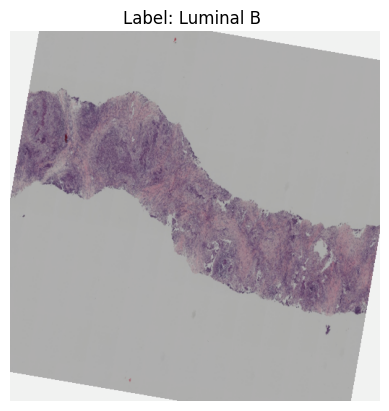

In [7]:
batch = next(iter(train_loader))
imgs, labels = batch
print(imgs.shape)    # expected: [BATCH_SIZE, 3, 512, 512]
print(labels.shape)  # [BATCH_SIZE]

# visualize one sample
import matplotlib.pyplot as plt

inv_mean = [-m/s for m, s in zip(imagenet_mean, imagenet_std)]
inv_std = [1/s for s in imagenet_std]

inv_norm = transforms.Normalize(mean=inv_mean, std=inv_std)

img0 = inv_norm(imgs[0]).permute(1, 2, 0).cpu().numpy()
img0 = np.clip(img0, 0, 1)

plt.imshow(img0)
plt.title(f"Label: {idx2label[int(labels[0])]} ")
plt.axis("off")
plt.show()


### Save Processed DataFrames

This section saves the processed training and test DataFrames using the `PersistenceManager` for future use in model training and evaluation.

In [8]:
PersistenceManager.save_dataset({
    "train_df": train_df,
    "test_df": test_df,
    "train_loader": train_loader,
    "val_loader": val_loader,
    "val_test_transforms": val_test_transforms,
    "idx2label": idx2label,
    "label2idx": label2idx
})

Arrays and scalers saved successfully to: /home/andre/university/AN2DL-Challenge-2/notebooks/processed/dataset.joblib
